# `interpret_IF.ipynb` -- how the IF predictor actually makes its predictions

`train_IF.ipynb` says the model works (blocked-split R2 ~0.09-0.10, AUROC ~0.69-0.74).
This notebook asks what it is *using* to get there, with five views that fail in
different ways -- so the parts they agree on are the parts worth believing:

| section | method | question it answers |
|---|---|---|
| 1 | **integrated gradients** (`models.interpret.integrated_gradients`) | which features carry the predicted signal, and in which direction |
| 1b | **permutation importance** | which of them the score actually *depends* on (the redundancy check IG can't do) |
| 2 | IG on each **hurdle branch** | presence (*is this cell positive*) vs level (*how bright*) -- learned from the same inputs, or different ones? |
| 3 | **partial dependence** | the *shape* of the response: monotone, saturating, thresholded? |
| 4 | **attribution maps** | where in the well each feature's influence lands -- pattern-following or artefact-following? |
| 5 | **edge sensitivity** | how much arrives through the graph rather than the cell's own columns |
| 6 | **counterfactual illumination** | what the model predicts for patterns that were never imaged -- i.e. is the learned rule a spatial dose-response or a memorised map? |

Integrated gradients is the primary tool because it is *exact* for this architecture:
attributions sum to `f(x) - f(baseline)` (checked, not assumed), it needs no surrogate
model the way SHAP-style methods do, and it handles the graph natively -- the gradient
already carries every message-passing path. Its one real weakness is correlated inputs,
which the pyramid scales badly are, and that is precisely what section 1b covers.

In [1]:
import sys, os
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

pd.set_option('display.width', 180)
plt.rcParams['figure.dpi'] = 110

In [2]:
import plotting as pl
import tools.evaluation as ev
from tools.dataset import load_well
from models import recipe
from models import interpret as ip
from models.predictors import IFPredictor
from models.graph import border_mask
from tools.morphology import indices_to_mask

In [3]:
PRIMARY_WELL = 'W9_pattern1_Sox17_Brachyury'
RESULTS = '/Users/allywang/Desktop/work/F2026/OptoBMP/results/figures'
FIG_DIR = f'{RESULTS}/{PRIMARY_WELL}/interpret'
os.makedirs(FIG_DIR, exist_ok=True)

DEVICE = 'cpu'        # gradients over the full graph; ~0.3 s per IG step here
IG_STEPS = 32         # error_mass ~5e-4 at 32 -- see integrated_gradients' docstring
MARKERS = ['Sox17', 'T']
SPLIT = 'blocked'     # the split whose model is on disk -- see the note below

## 0. Rebuild exactly what was trained

A checkpoint holds **weights only** -- no scaler, no split, no `log_w`. All three have to
be reconstructed identically or every attribution below describes a model/input pair that
never existed, with no error to warn you. So this section repeats `train_IF.ipynb`'s setup
verbatim and then *checks* the reconstruction by scoring it.

Two things to know about the checkpoints on disk:

* `train_IF.ipynb` saves inside its `for split_style in ['random', 'blocked']` loop to a
  path that doesn't include the split, so **the file is the blocked-split model** (written
  last). That is the better one to interpret anyway -- it is the one whose score isn't
  inflated by neighbouring cells sitting on both sides of the split -- but the random-split
  model is not recoverable. Add `{split_style}` to the filename there if you want both.
* `log_w` is recomputed here with `ip.train_log_w`. Worth a look at the cross-well cell in
  `train_IF.ipynb`: it passes `((N - n_pos) / n_pos)` as `log_w`, which is `w`, not
  `log(w)` -- `sigmoid(logit - 5.2)` instead of `sigmoid(logit - 1.65)`. That over-corrects
  the prior and pushes R2 down without touching AUROC, which is exactly the R2/AUROC
  disagreement in that table's negative R2 rows.

In [4]:
df = load_well(PRIMARY_WELL)
centroids = df[['centroid_y', 'centroid_x']].to_numpy(np.float32)

IF_BACKGROUNDS = df[['Sox17_mean', 'T_mean', 'BMP4_mean']].mean().to_dict()
BACKGROUNDS = recipe.normalize(df, ['BMP4_mean', 'Sox17_mean', 'T_mean'], backgrounds=IF_BACKGROUNDS)

X_INTENSITY = recipe.intensity_features(df, 'BMP4_mean', max_sigma=recipe.MAX_SIGMA)
X_MASK = recipe.mask_features(df, 'BMP4_bin', max_sigma=recipe.MAX_SIGMA, geometry=True)
FEATURE_SETS = {'BMP4_mask': X_MASK, 'BMP4_intensities': X_INTENSITY}

shape = (int(centroids[:,0].max())+2, int(centroids[:,1].max())+2)
valid = np.where(~border_mask(centroids, shape, recipe.RADIUS))[0]
SPLITS = {
    'random':  tuple(valid[i] for i in ev.random_split(len(valid), seed=0)),
    'blocked': tuple(valid[i] for i in ev.spatial_block_split(centroids[valid], block=800.0, seed=0)),
}
MASKS = {k: tuple(indices_to_mask(i, len(df)) for i in v) for k, v in SPLITS.items()}
tr, va, te = SPLITS[SPLIT]
trm, vam, tem = MASKS[SPLIT]
print(f'{SPLIT}: train/val/test = {len(tr):,}/{len(va):,}/{len(te):,}')

blocked: train/val/test = 75,221/16,284/14,854


In [5]:
M, rows = {}, []
for fname, cols in FEATURE_SETS.items():
    for marker in MARKERS:
        y_col = f'{marker}_mean'
        model = IFPredictor.load_checkpoint(
            f'../results/models/{PRIMARY_WELL}/{marker}_{fname}.pt', device=DEVICE)
        data = recipe.build_data(df, cols, y_col, tr)      # SAME train_idx -> same scaler
        log_w = ip.train_log_w(data, trm)                  # SAME split -> same prior correction
        met = ip.check_reconstruction(model, data, log_w, tem, device=DEVICE)
        M[(marker, fname)] = dict(model=model, data=data, log_w=log_w, cols=cols)
        rows.append(dict(target=marker, features=fname, log_w=log_w, **met))

reconstruction = pd.DataFrame(rows)
reconstruction.round(4)

,target,features,log_w,r2,pearson,spearman,auroc,ap,base_rate,r2_positives
0,Sox17,BMP4_mask,1.5762,0.0854,0.3097,0.3065,0.7398,0.3126,0.1564,-3.6099
1,T,BMP4_mask,0.5063,0.1005,0.3290,0.3217,0.6948,0.4806,0.3265,-6.6448
2,Sox17,BMP4_intensities,1.5762,0.0877,0.3086,0.2977,0.7321,0.3146,0.1564,-3.6967
3,T,BMP4_intensities,0.5063,0.0749,0.2923,0.2882,0.6725,0.4559,0.3265,-6.9102


These `r2`/`auroc` must match `train_IF.ipynb`'s **blocked** rows to the digit. They do
(Sox17 mask 0.0854 / 0.740, T mask 0.1005 / 0.695, Sox17 intensity 0.0877 / 0.732,
T intensity 0.0749 / 0.673) -- the scaler, split and prior correction are the trained ones,
so everything below is about the real model.

## 1. Which features carry the prediction

**Baseline choice is the whole experiment.** IG explains `f(x) - f(baseline)`, so the
baseline defines the question. The natural one here is an **unstimulated cell**: the mean
feature vector of cells furthest from any BMP4+ cell. Attributions then read as *"this much
of the predicted signal exists because of the illumination pattern"*.

(The default zeros baseline answers a much weaker question -- zero is the *train mean* of
each standardized column, i.e. an average cell of this well, which predicts almost exactly
the average, so there is nearly nothing to attribute. See `integrated_gradients`' docstring
for the completeness arithmetic.)

The explained cells are the non-border ones -- border cells have truncated neighbourhoods
by construction (`border_mask`), and were never trained on.

In [6]:
UNSTIM = (df['BMP4_bin_log_dist_pos'] >= df['BMP4_bin_log_dist_pos'].quantile(0.95)).to_numpy()
EXPLAIN = indices_to_mask(valid, len(df)).numpy()
print(f'unstimulated reference: {UNSTIM.sum():,} cells   explained: {EXPLAIN.sum():,} cells')

IG = {}
for key, m in M.items():
    base = ip.reference_baseline(m['data'], UNSTIM)
    IG[key] = ip.integrated_gradients(m['model'], m['data'], m['log_w'], baseline=base,
                                      steps=IG_STEPS, nodes=EXPLAIN, device=DEVICE, verbose=False)
    r = IG[key]
    print(f"{key[0]:6s} {key[1]:17s}  f(x)={r['f_x']:8.1f}  f(baseline)={r['f_baseline']:7.1f}  "
          f"attributed={r['total']:8.1f}  ({r['total']/r['f_x']:.0%} of predicted signal)  "
          f"completeness err={r['error_mass']:.2e}")

unstimulated reference: 5,415 cells   explained: 106,359 cells


/Users/allywang/Desktop/work/F2026/OptoBMP/notebooks/../src/models/interpret.py:165: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  t = torch.as_tensor(np.asarray(nodes))


Sox17  BMP4_mask          f(x)=  8160.6  f(baseline)= 3594.7  attributed=  4576.9  (56% of predicted signal)  completeness err=3.37e-04


T      BMP4_mask          f(x)= 19826.1  f(baseline)=15035.7  attributed=  4860.5  (25% of predicted signal)  completeness err=1.52e-03


Sox17  BMP4_intensities   f(x)=  8156.9  f(baseline)= 2157.2  attributed=  6021.6  (74% of predicted signal)  completeness err=1.34e-03


T      BMP4_intensities   f(x)= 19721.5  f(baseline)=17534.2  attributed=  2166.3  (11% of predicted signal)  completeness err=6.99e-04


`attributed / f(x)` is worth reading on its own: it is the fraction of all predicted
signal in the well that the illumination features explain relative to an unstimulated cell.
The remainder is what the model predicts for a cell with no BMP4 anywhere near it -- the
baseline rate it cannot get below.

total    mean  mean_abs   share  frac_positive
                       feature                                                                    
Sox17/BMP4_mask        BMP4_bin_gauss_120    -8480.945312 -0.0783    0.0951  0.3158         0.2132
                       BMP4_bin_gauss_240     6638.888672  0.0613    0.0664  0.2203         0.8176
                       BMP4_bin_log_dist_pos  4817.694824  0.0445    0.0534  0.1774         0.7959
                       BMP4_bin_gauss_60      4458.381836  0.0412    0.0487  0.1618         0.8827
                       BMP4_bin_log_dist_neg -1333.386597 -0.0123    0.0126  0.0420         0.8142
                       BMP4_bin_gauss_15     -1186.002808 -0.0110    0.0126  0.0418         0.0208
                       BMP4_bin_gauss_30      -602.531982 -0.0056    0.0098  0.0326         0.5732
                       BMP4_bin                264.838104  0.0024    0.0025  0.0083         0.0290
T/BMP4_mask            BMP4_bin_gauss_120    -3811.435547 -0.0352    0.1129  0.2647         0.5516
                       BMP4_bin_log_dist_pos  7692.696777  0.0710    0.0844  0.1981         0.8512
                       BMP4_bin_gauss_240     3713.275146  0.0343    0.0606  0.1421         0.6137
                       BMP4_bin_gauss_60      1390.273682  0.0128    0.0569  0.1334         0.2625
                       BMP4_bin_log_dist_neg -5181.089355 -0.0478    0.0478  0.1122         0.6777
                       BMP4_bin_gauss_15      2135.331543  0.0197    0.0313  0.0733         0.1973
                       BMP4_bin_gauss_30     -1701.854248 -0.0157    0.0266  0.0625         0.3505
                       BMP4_bin                623.295593  0.0058    0.0058  0.0137         0.0282
Sox17/BMP4_intensities BMP4_mean_mean_60      3559.513672  0.0329    0.0417  0.2762         0.6879
                       BMP4_mean_mean_120     -977.908325 -0.0090    0.0351  0.2324         0.5336
                       BMP4_mean_mean_240     2850.408447  0.0263    0.0321  0.2125         0.7605
                       BMP4_mean_mean_30      1006.483826  0.0093    0.0247  0.1636         0.4450
                       BMP4_mean                76.631203  0.0007    0.0094  0.0621         0.0615
                       BMP4_mean_mean_15      -493.558594 -0.0046    0.0080  0.0531         0.3763
T/BMP4_intensities     BMP4_mean_mean_60     -2003.750977 -0.0185    0.0743  0.2680         0.4123
                       BMP4_mean_mean_120     4912.750488  0.0454    0.0724  0.2609         0.7113
                       BMP4_mean_mean_240     1064.826172  0.0098    0.0443  0.1596         0.6271
                       BMP4_mean             -2770.006836 -0.0256    0.0337  0.1215         0.7102
                       BMP4_mean_mean_30       815.127808  0.0075    0.0298  0.1074         0.4964
                       BMP4_mean_mean_15       147.380295  0.0014    0.0229  0.0825         0.3140

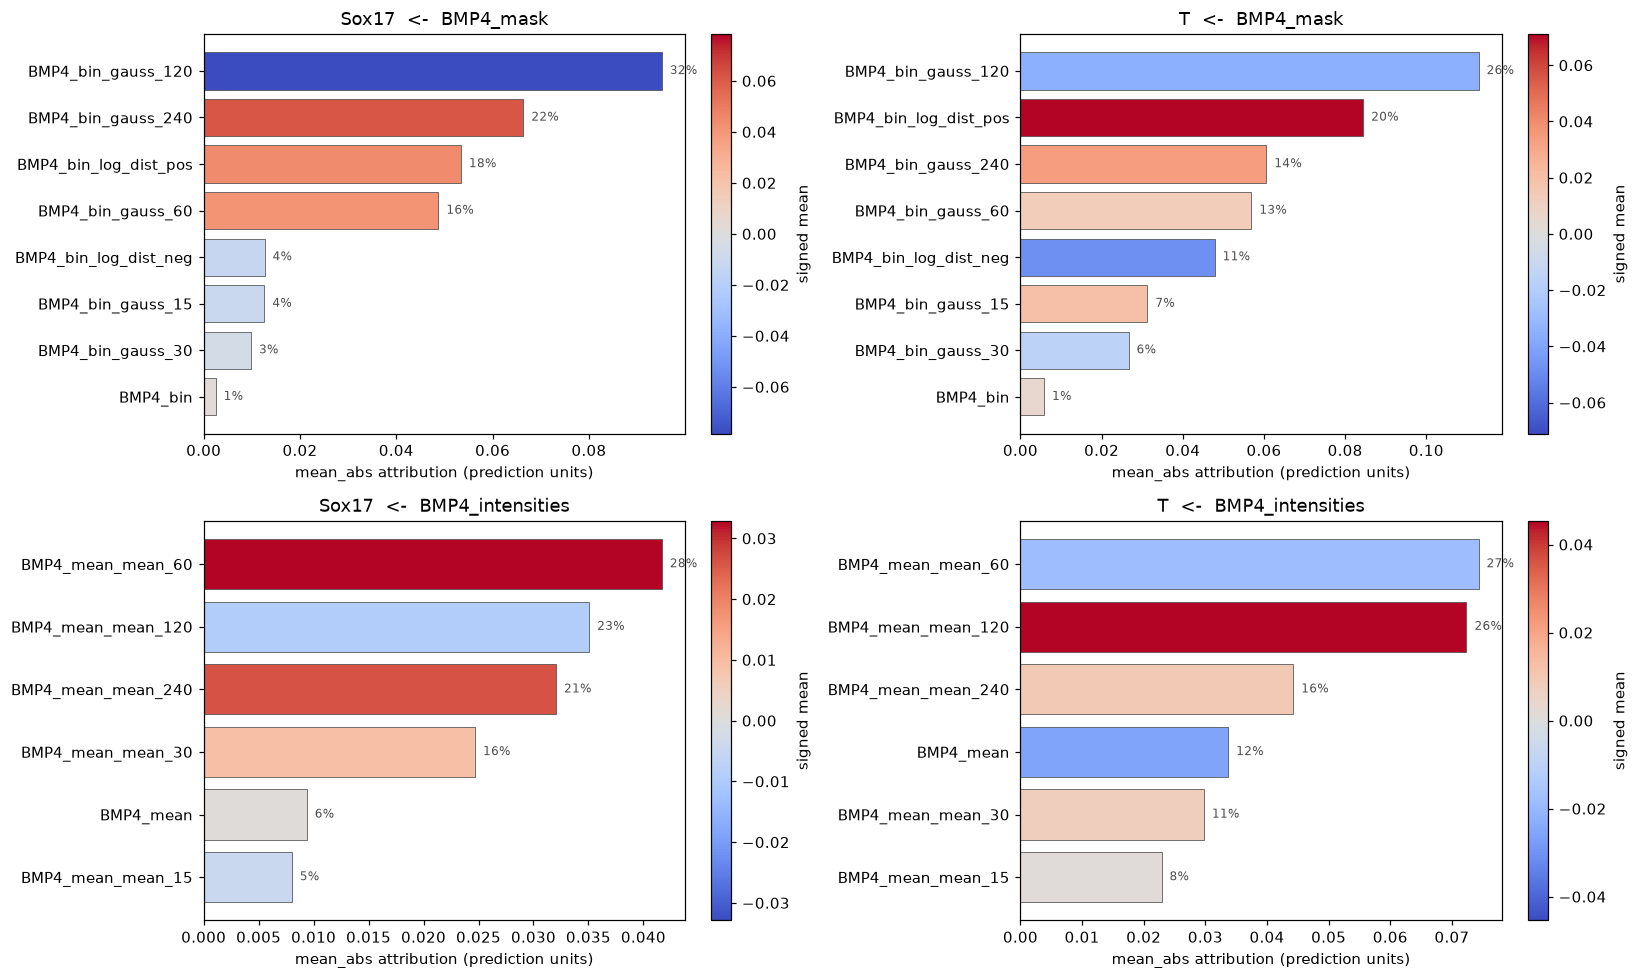

In [7]:
TABLES = {k: ip.attribution_table(ig) for k, ig in IG.items()}

fig, axs = plt.subplots(2, 2, figsize=(15, 9))
for ax, (key, t) in zip(axs.ravel(), TABLES.items()):
    pl.plot_attribution_bars(t, ax=ax, title=f'{key[0]}  <-  {key[1]}')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ig_attribution.png', dpi=130)

pd.concat({f'{k[0]}/{k[1]}': t.set_index('feature') for k, t in TABLES.items()}).round(4)

### 1b. The redundancy check: permutation importance

IG says where the model's credit goes; it cannot say whether the model *needed* that
feature, because two ~0.9-correlated pyramid scales can trade credit freely. Shuffling a
column across cells and re-scoring answers the other half: **how much score is lost if this
feature is destroyed**. A feature that is high on both is genuinely load-bearing; high IG
with zero drop means redundant, not unimportant.

The column is shuffled for *every* cell, not just the evaluated ones -- a node's features
reach its neighbours' predictions through the graph.

r2_drop  auroc_drop  spearman_drop
                       feature                                                  
Sox17/BMP4_mask        BMP4_bin_gauss_240      0.1622      0.0409         0.0537
                       BMP4_bin_log_dist_pos   0.1347      0.2032         0.2651
                       BMP4_bin_gauss_60       0.1227      0.1251         0.1646
                       BMP4_bin_log_dist_neg   0.1058      0.0380         0.0470
                       BMP4_bin_gauss_120      0.0464      0.0448         0.0598
                       BMP4_bin_gauss_15       0.0363      0.0229         0.0309
                       BMP4_bin_gauss_30       0.0155      0.0252         0.0310
                       BMP4_bin               -0.0003      0.0018         0.0027
T/BMP4_mask            BMP4_bin_gauss_15       0.6878      0.0514         0.0904
                       BMP4_bin_log_dist_neg   0.3589      0.1391         0.2250
                       BMP4_bin_gauss_120      0.1308      0.0737         0.1131
                       BMP4_bin_gauss_60       0.1230      0.0681         0.1152
                       BMP4_bin_gauss_30       0.0824      0.0429         0.0663
                       BMP4_bin_log_dist_pos   0.0458      0.0120         0.0221
                       BMP4_bin                0.0125      0.0014         0.0026
                       BMP4_bin_gauss_240      0.0098      0.0077         0.0135
Sox17/BMP4_intensities BMP4_mean_mean_60       0.0945      0.1086         0.1426
                       BMP4_mean_mean_30       0.0887      0.1150         0.1533
                       BMP4_mean_mean_120      0.0605      0.0776         0.1029
                       BMP4_mean_mean_15       0.0391      0.0724         0.0933
                       BMP4_mean_mean_240      0.0280      0.0461         0.0612
                       BMP4_mean               0.0240      0.0248         0.0342
T/BMP4_intensities     BMP4_mean_mean_60       0.1925      0.1336         0.2211
                       BMP4_mean               0.1043      0.0531         0.0935
                       BMP4_mean_mean_120      0.0703      0.0353         0.0645
                       BMP4_mean_mean_30       0.0488      0.0336         0.0583
                       BMP4_mean_mean_15       0.0207      0.0090         0.0200
                       BMP4_mean_mean_240      0.0019      0.0046         0.0119

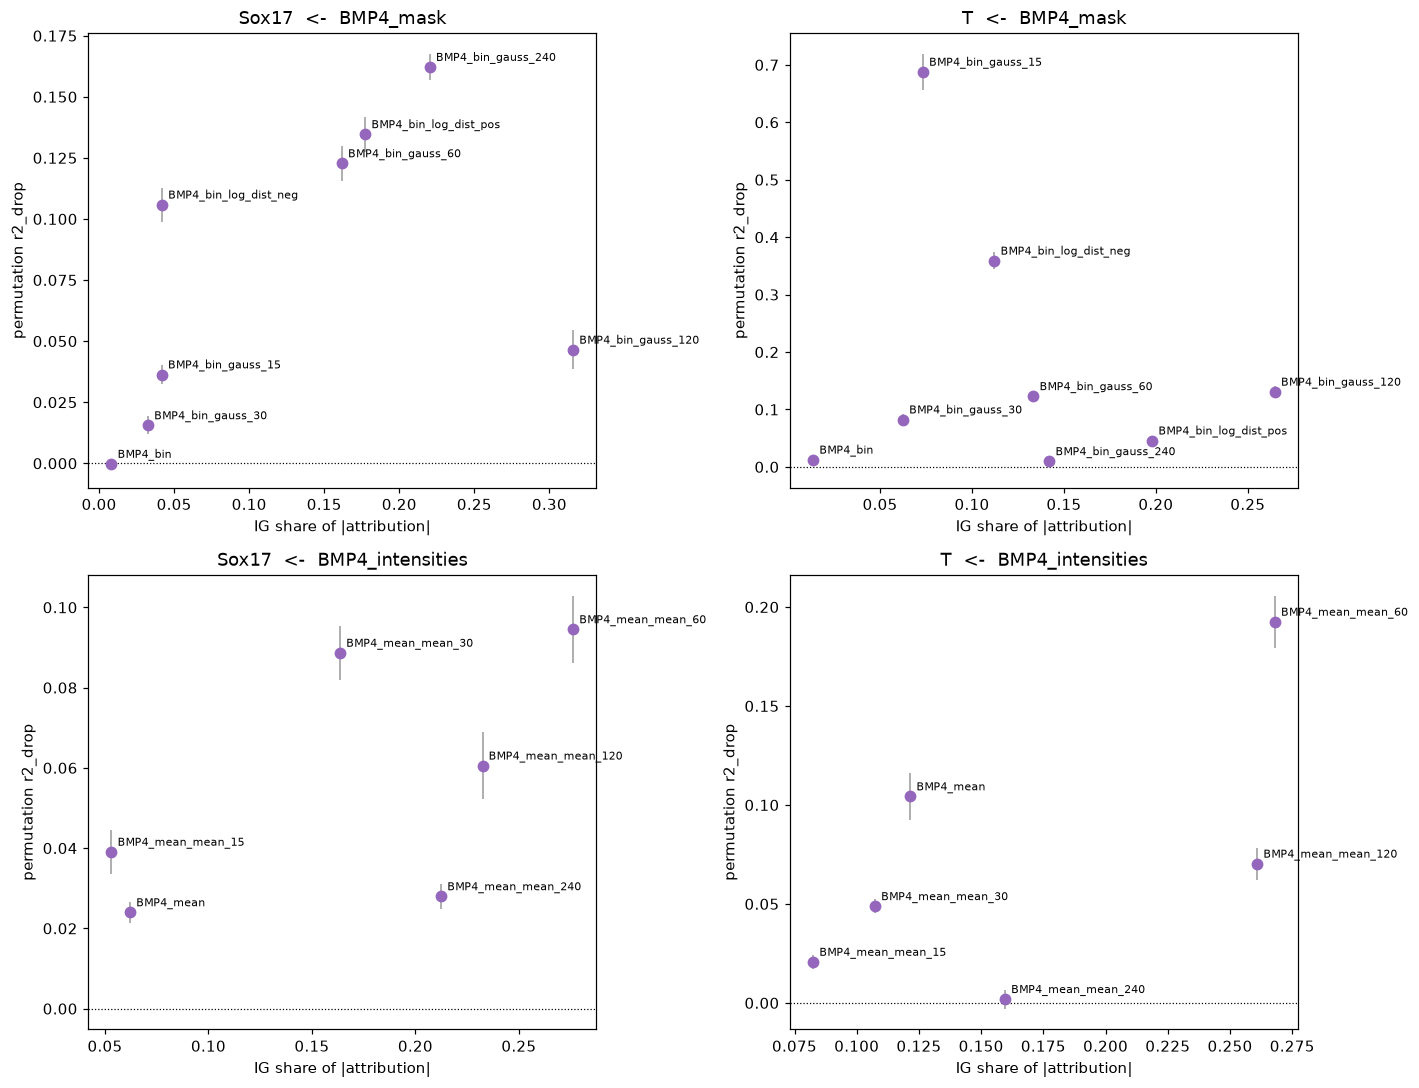

In [8]:
PERM = {}
for key, m in M.items():
    PERM[key] = ip.permutation_importance(m['model'], m['data'], m['log_w'], tem,
                                          n_repeats=5, device=DEVICE, verbose=False)

fig, axs = plt.subplots(2, 2, figsize=(13, 10))
for ax, key in zip(axs.ravel(), TABLES):
    pl.plot_importance_comparison(TABLES[key], PERM[key], ax=ax, title=f'{key[0]}  <-  {key[1]}')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/importance_comparison.png', dpi=130)

pd.concat({f'{k[0]}/{k[1]}': p.set_index('feature')[['r2_drop', 'auroc_drop', 'spearman_drop']]
           for k, p in PERM.items()}).round(4)

## 2. Presence vs level: the two hurdle branches

`TwoPartHead` predicts `sigmoid(logit - log_w) * magnitude` -- a classifier ("is this cell
positive") times a level ("how bright, given positive"). A combined attribution averages the
two, hiding the case that matters: a feature that decides *whether* a cell responds but not
*how strongly* (or the reverse).

The magnitude branch is only ever supervised on truly-positive cells (see `TwoPartHead`),
so it is explained on those cells only -- its attributions elsewhere describe an
unconstrained function.

Sox17: 18,522 positive cells explained for the magnitude branch


T: 39,014 positive cells explained for the magnitude branch


Sox17/logit        Sox17/magnitude        T/logit        T/magnitude       
                            share   mean           share   mean   share   mean       share   mean
feature                                                                                          
BMP4_bin_gauss_120          0.309 -2.482           0.180 -0.003   0.182 -0.484       0.313  0.005
BMP4_bin_gauss_240          0.203  1.607           0.116  0.002   0.116  0.119       0.127  0.000
BMP4_bin_log_dist_pos       0.187  1.543           0.147  0.003   0.184  1.058       0.305  0.009
BMP4_bin_gauss_60           0.139  0.760           0.413  0.017   0.132  0.352       0.100  0.001
BMP4_bin_log_dist_neg       0.066 -0.579           0.038 -0.002   0.184 -1.171       0.065 -0.002
BMP4_bin_gauss_15           0.050 -0.444           0.028 -0.001   0.094  0.493       0.043  0.001
BMP4_bin_gauss_30           0.033 -0.008           0.073 -0.003   0.086 -0.463       0.040 -0.001
BMP4_bin                    0.014  0.125           0.005  0.000   0.023  0.146       0.007  0.000

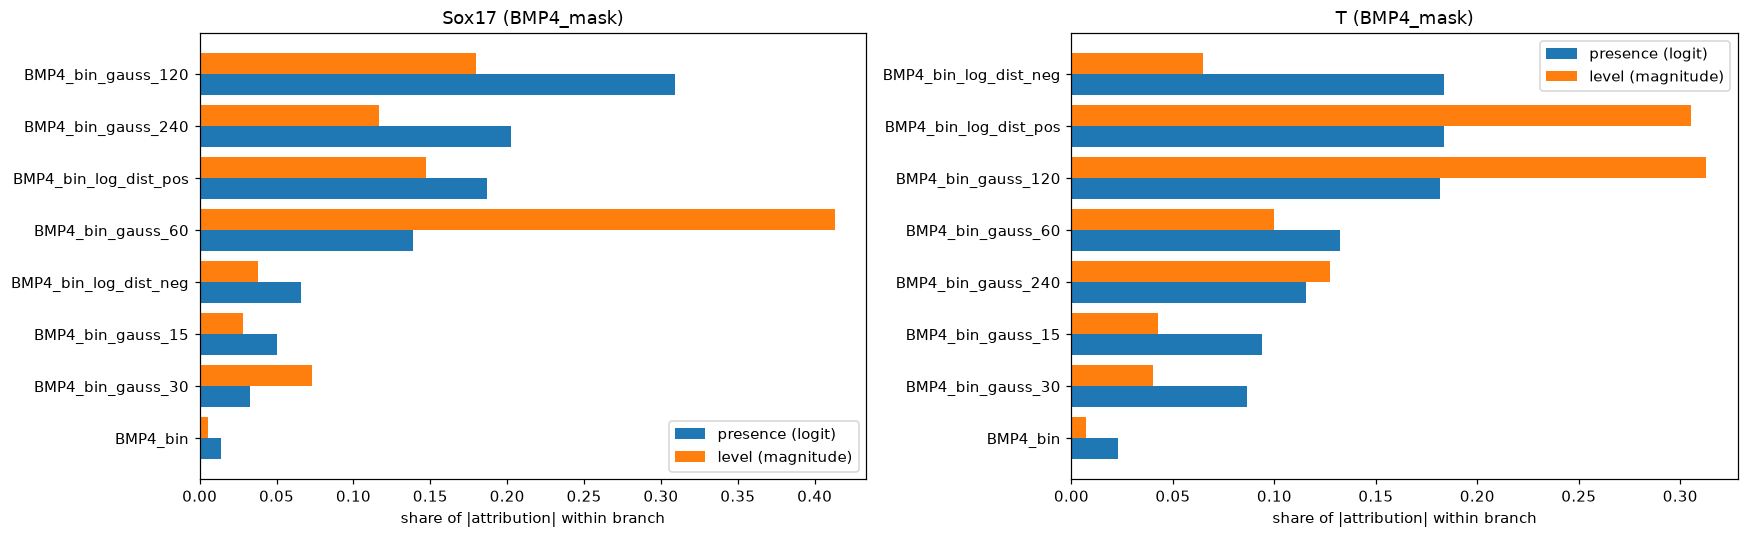

In [9]:
BRANCH = {}
for marker in MARKERS:
    key = (marker, 'BMP4_mask')
    m = M[key]
    base = ip.reference_baseline(m['data'], UNSTIM)
    pos = (m['data']['y_positive'].numpy().ravel() > 0.5) & EXPLAIN
    for target, nodes in [('logit', EXPLAIN), ('magnitude', pos)]:
        ig = ip.integrated_gradients(m['model'], m['data'], m['log_w'], target=target,
                                     baseline=base, steps=IG_STEPS, nodes=nodes,
                                     device=DEVICE, verbose=False)
        BRANCH[(marker, target)] = ip.attribution_table(ig)
    print(f'{marker}: {pos.sum():,} positive cells explained for the magnitude branch')

fig, axs = plt.subplots(1, 2, figsize=(16, 5))
for ax, marker in zip(axs, MARKERS):
    pl.plot_branch_attribution(BRANCH[(marker, 'logit')], BRANCH[(marker, 'magnitude')],
                               ax=ax, title=f'{marker} (BMP4_mask)')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/branch_attribution.png', dpi=130)

pd.concat({f'{k[0]}/{k[1]}': t.set_index('feature')[['share', 'mean']]
           for k, t in BRANCH.items()}, axis=1).round(3)

## 3. The shape of the response

Importance rankings say *how much*; partial dependence says *what happens*. Each feature is
swept across its observed 1st-99th percentile range **for every cell at once** (the honest
counterfactual for a graph model -- a per-cell sweep would leave the neighbours at their
real values and lose whatever arrives through the graph), with everything else untouched.

Faint lines are individual cells (ICE). If they fan out, the mean curve is an average over
cells that behave differently and should not be quoted alone. The far ends of each curve are
extrapolation -- setting `gauss_240` high while `gauss_15` keeps its real value describes a
field no illumination pattern can produce -- so read the middle.

One panel per feature, each on its own x axis: a mask fraction lives in [0, 0.4] and a
log-distance in [0, 6], so sharing an axis would squash every fraction curve into the
left-hand edge.

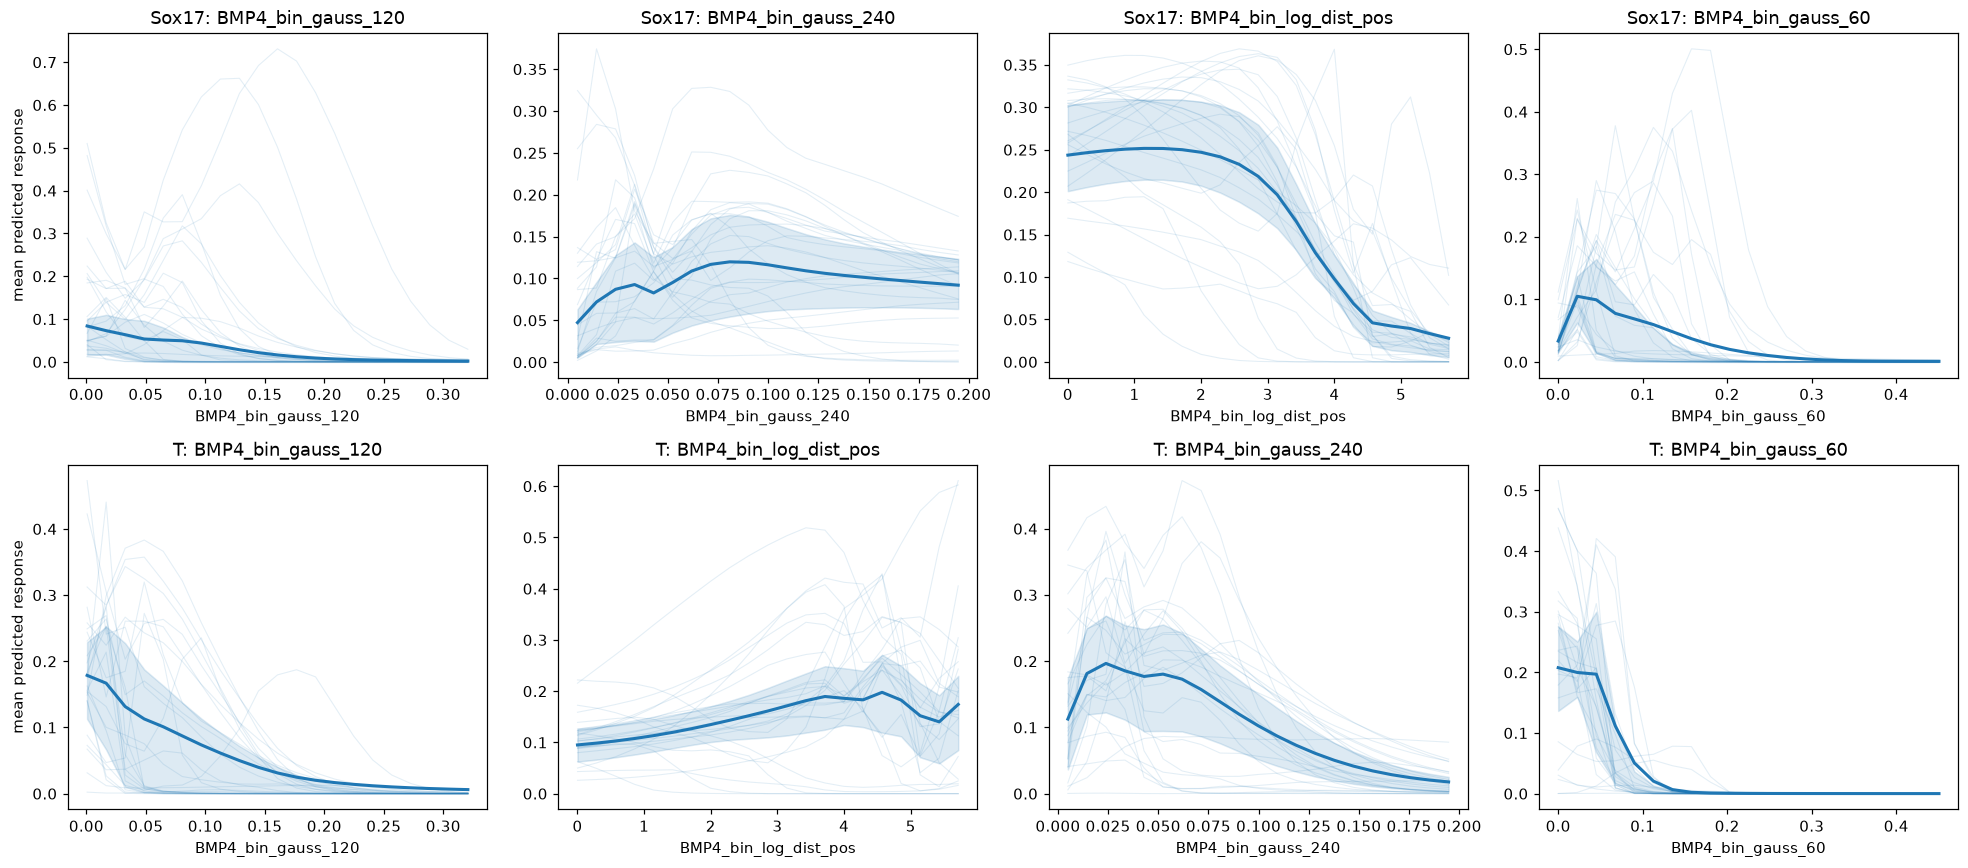

In [10]:
PD = {}
for marker in MARKERS:
    key = (marker, 'BMP4_mask')
    m = M[key]
    top = TABLES[key]['feature'].head(4).tolist()
    PD[marker] = {f: ip.partial_dependence(m['model'], m['data'], m['log_w'], f, n_grid=21,
                                           nodes=EXPLAIN, n_ice=25, device=DEVICE, verbose=False)
                  for f in top}

fig, axs = plt.subplots(2, 4, figsize=(18, 8))
for i, marker in enumerate(MARKERS):
    for ax, (feat, curve) in zip(axs[i], PD[marker].items()):
        pl.plot_partial_dependence({feat: curve}, ax=ax, legend=False, xlabel=feat,
                                   title=f'{marker}: {feat}')
    for ax in axs[i][1:]:
        ax.set_ylabel('')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/partial_dependence.png', dpi=130)

## 4. Where in the well the attributions land

Per-cell attribution, mapped. This is the check that no score can give you: an attribution
map that follows the illumination pattern is the model using the pattern; one that follows
the image edges, or a density gradient, is the model using an artefact that happens to
correlate with the readout in this well. That is the failure the blocked split exists to
detect -- here you can see it directly instead of inferring it from a score gap.

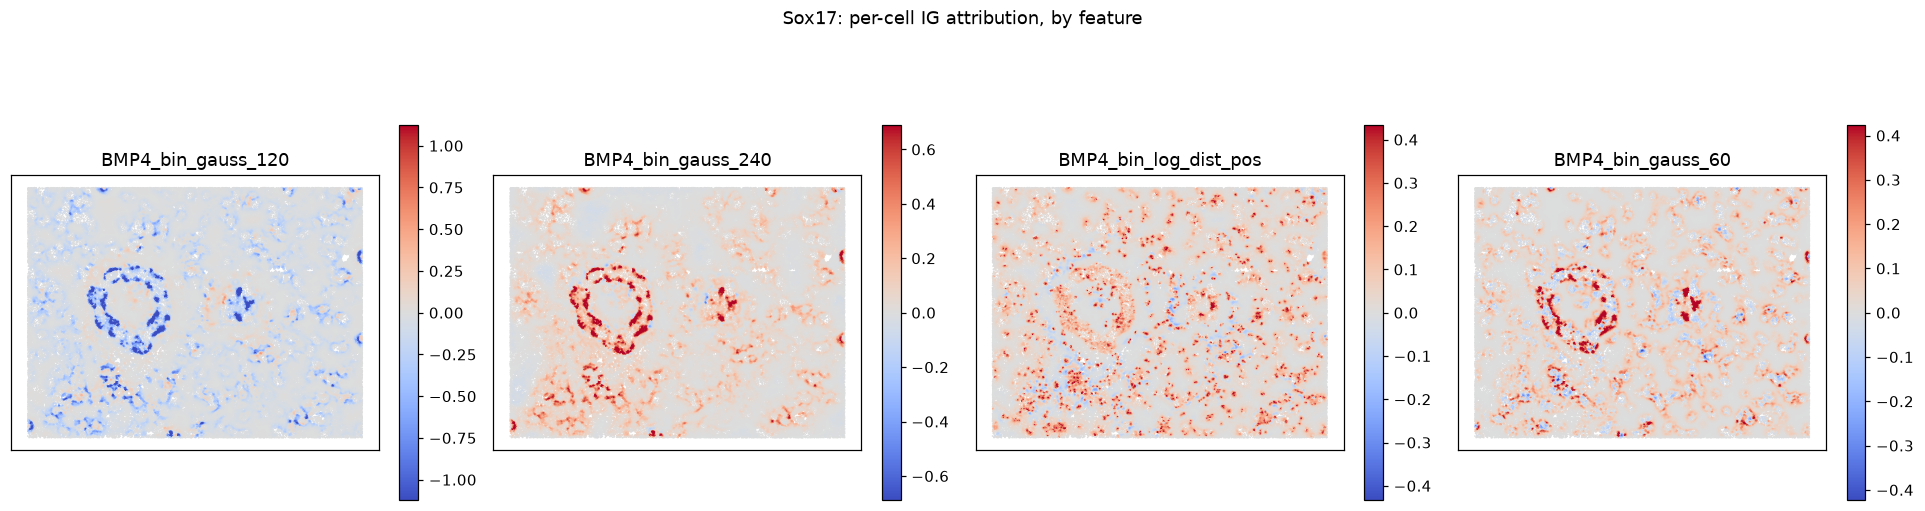

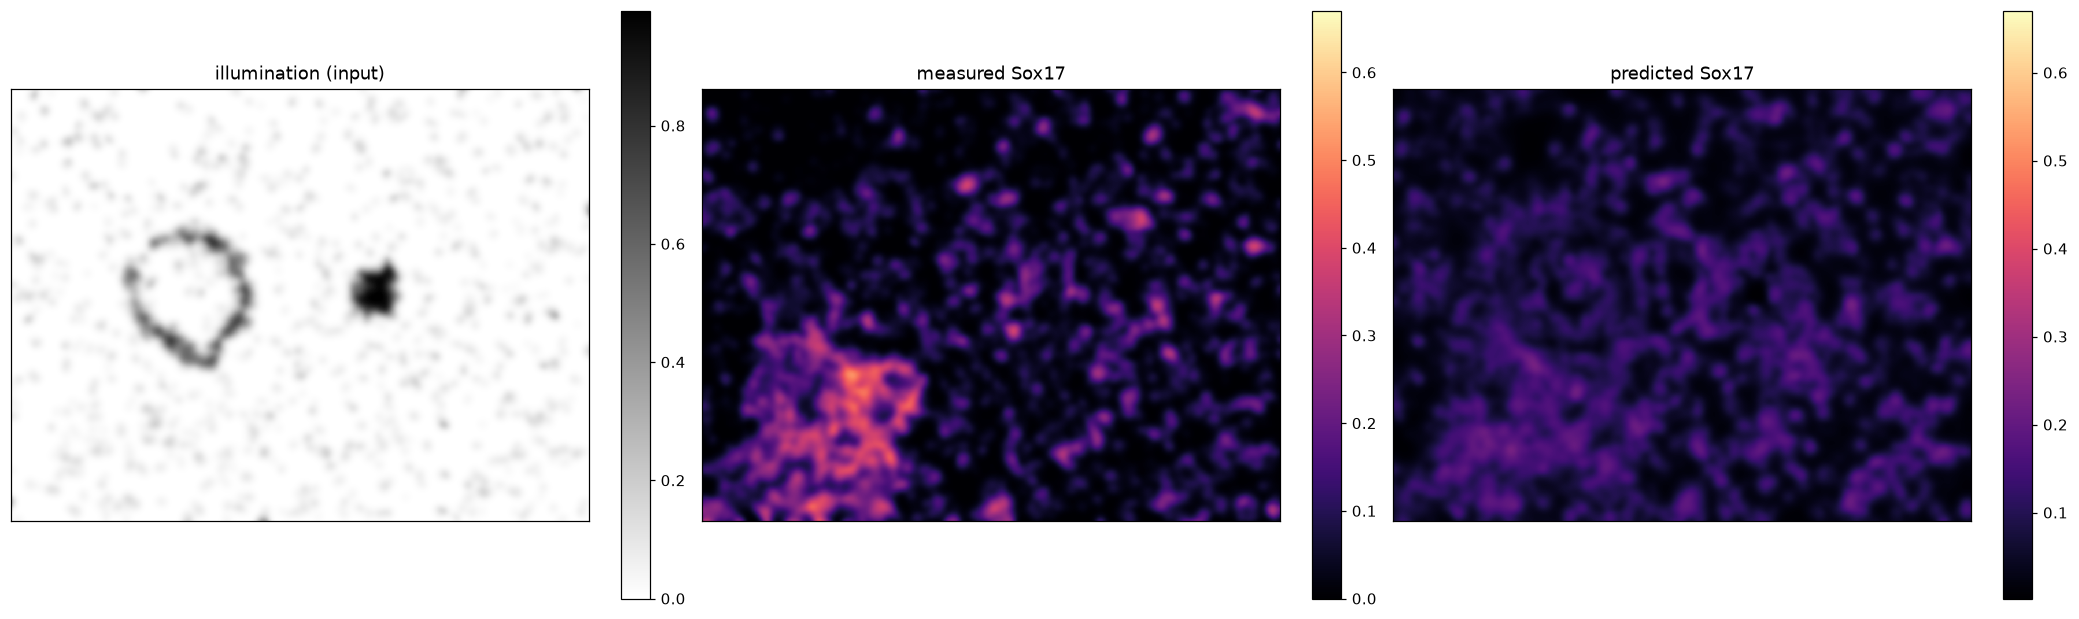

In [11]:
key = ('Sox17', 'BMP4_mask')
feats = TABLES[key]['feature'].head(4).tolist()
fig = pl.plot_attribution_maps(df, IG[key], feats, ncols=4, figsize_per=(4.4, 5.4),
                               suptitle=f'{key[0]}: per-cell IG attribution, by feature')
fig.savefig(f'{FIG_DIR}/attribution_maps.png', dpi=120)

fig = pl.plot_prediction_panel(df, 'BMP4_bin', M[key]['data']['y'].numpy().ravel(),
                               ip.predict(M[key]['model'], M[key]['data'], M[key]['log_w']),
                               target_name='Sox17', mask_name='illumination (input)', smooth_sigma=60)
fig.savefig(f'{FIG_DIR}/prediction_reference.png', dpi=120)

## 5. How much of this is the graph at all?

The inputs are *already* multi-scale neighbourhood summaries, so the model could in
principle ignore message passing entirely and read everything off each cell's own columns.
`edge_sensitivity` settles it: it takes each layer's per-edge message (grad x message, the
standard attribution) and bins it by the physical distance between the two cells the edge
connects. Distance 0 is the self-loop `build_radius_graph` adds for every node -- so the bar
at the left is literally "the cell's own features" and the curve is "its neighbours'".

Worth holding against the architecture: 3 layers x `radius=30` reaches ~90px, while the
largest pyramid feature summarises 240px. Long-range context is *supposed* to arrive as node
features; the graph's job is only local smoothing.

,Sox17/BMP4_mask,T/BMP4_mask,Sox17/BMP4_intensities,T/BMP4_intensities
"self-loop share, by layer",,,,
0,0.279,0.273,0.264,0.286
1,0.238,0.254,0.269,0.243
2,0.268,0.267,0.270,0.266


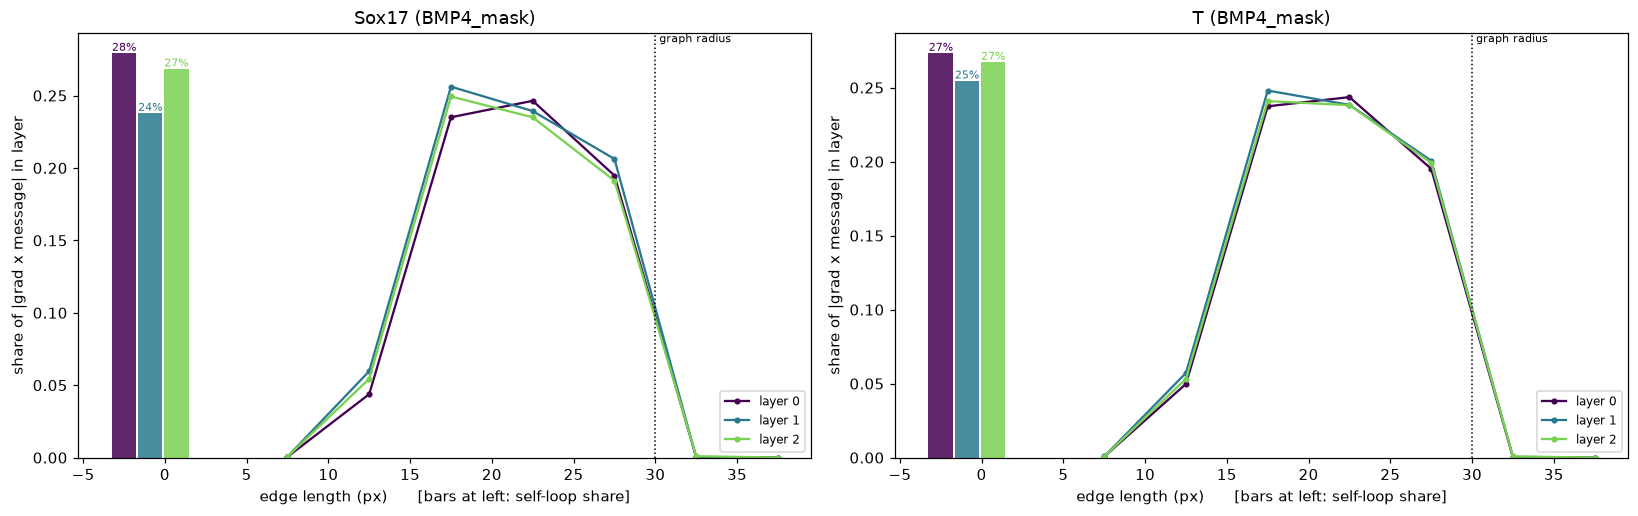

In [12]:
ES = {k: ip.edge_sensitivity(m['model'], m['data'], centroids, device=DEVICE)
      for k, m in M.items()}

fig, axs = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, marker in zip(axs, MARKERS):
    pl.plot_edge_sensitivity(ES[(marker, 'BMP4_mask')], ax=ax, radius=recipe.RADIUS,
                             title=f'{marker} (BMP4_mask)')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/edge_sensitivity.png', dpi=130)

pd.concat({f'{k[0]}/{k[1]}': t[t.self_loop].groupby('layer')['share'].sum()
           for k, t in ES.items()}, axis=1).round(3).rename_axis('self-loop share, by layer')

## 6. Counterfactual illumination: is it a rule or a map?

Everything above explains the fit. This asks whether the model learned a **spatial
dose-response** or a **memorised map of this well's pattern** -- and it is the one section
whose answer isn't already implied by the training metrics.

The illuminated mask is replaced by synthetic discs of varying radius, the mask pyramid is
recomputed from scratch (so the counterfactual stays physically realisable -- nudging the
scaled features directly would produce a 240px fraction contradicting the 15px one), and the
**fitted** scaler and the **unchanged** graph are reused (cell positions never move).

If the model learned a rule, a bigger disc gives a bigger responding region with the same
edge profile, and the response extends a characteristic distance beyond the disc edge. If it
memorised, the prediction stays pinned to where the real pattern was.

Absolute levels here are extrapolation -- the *shape* is the result.

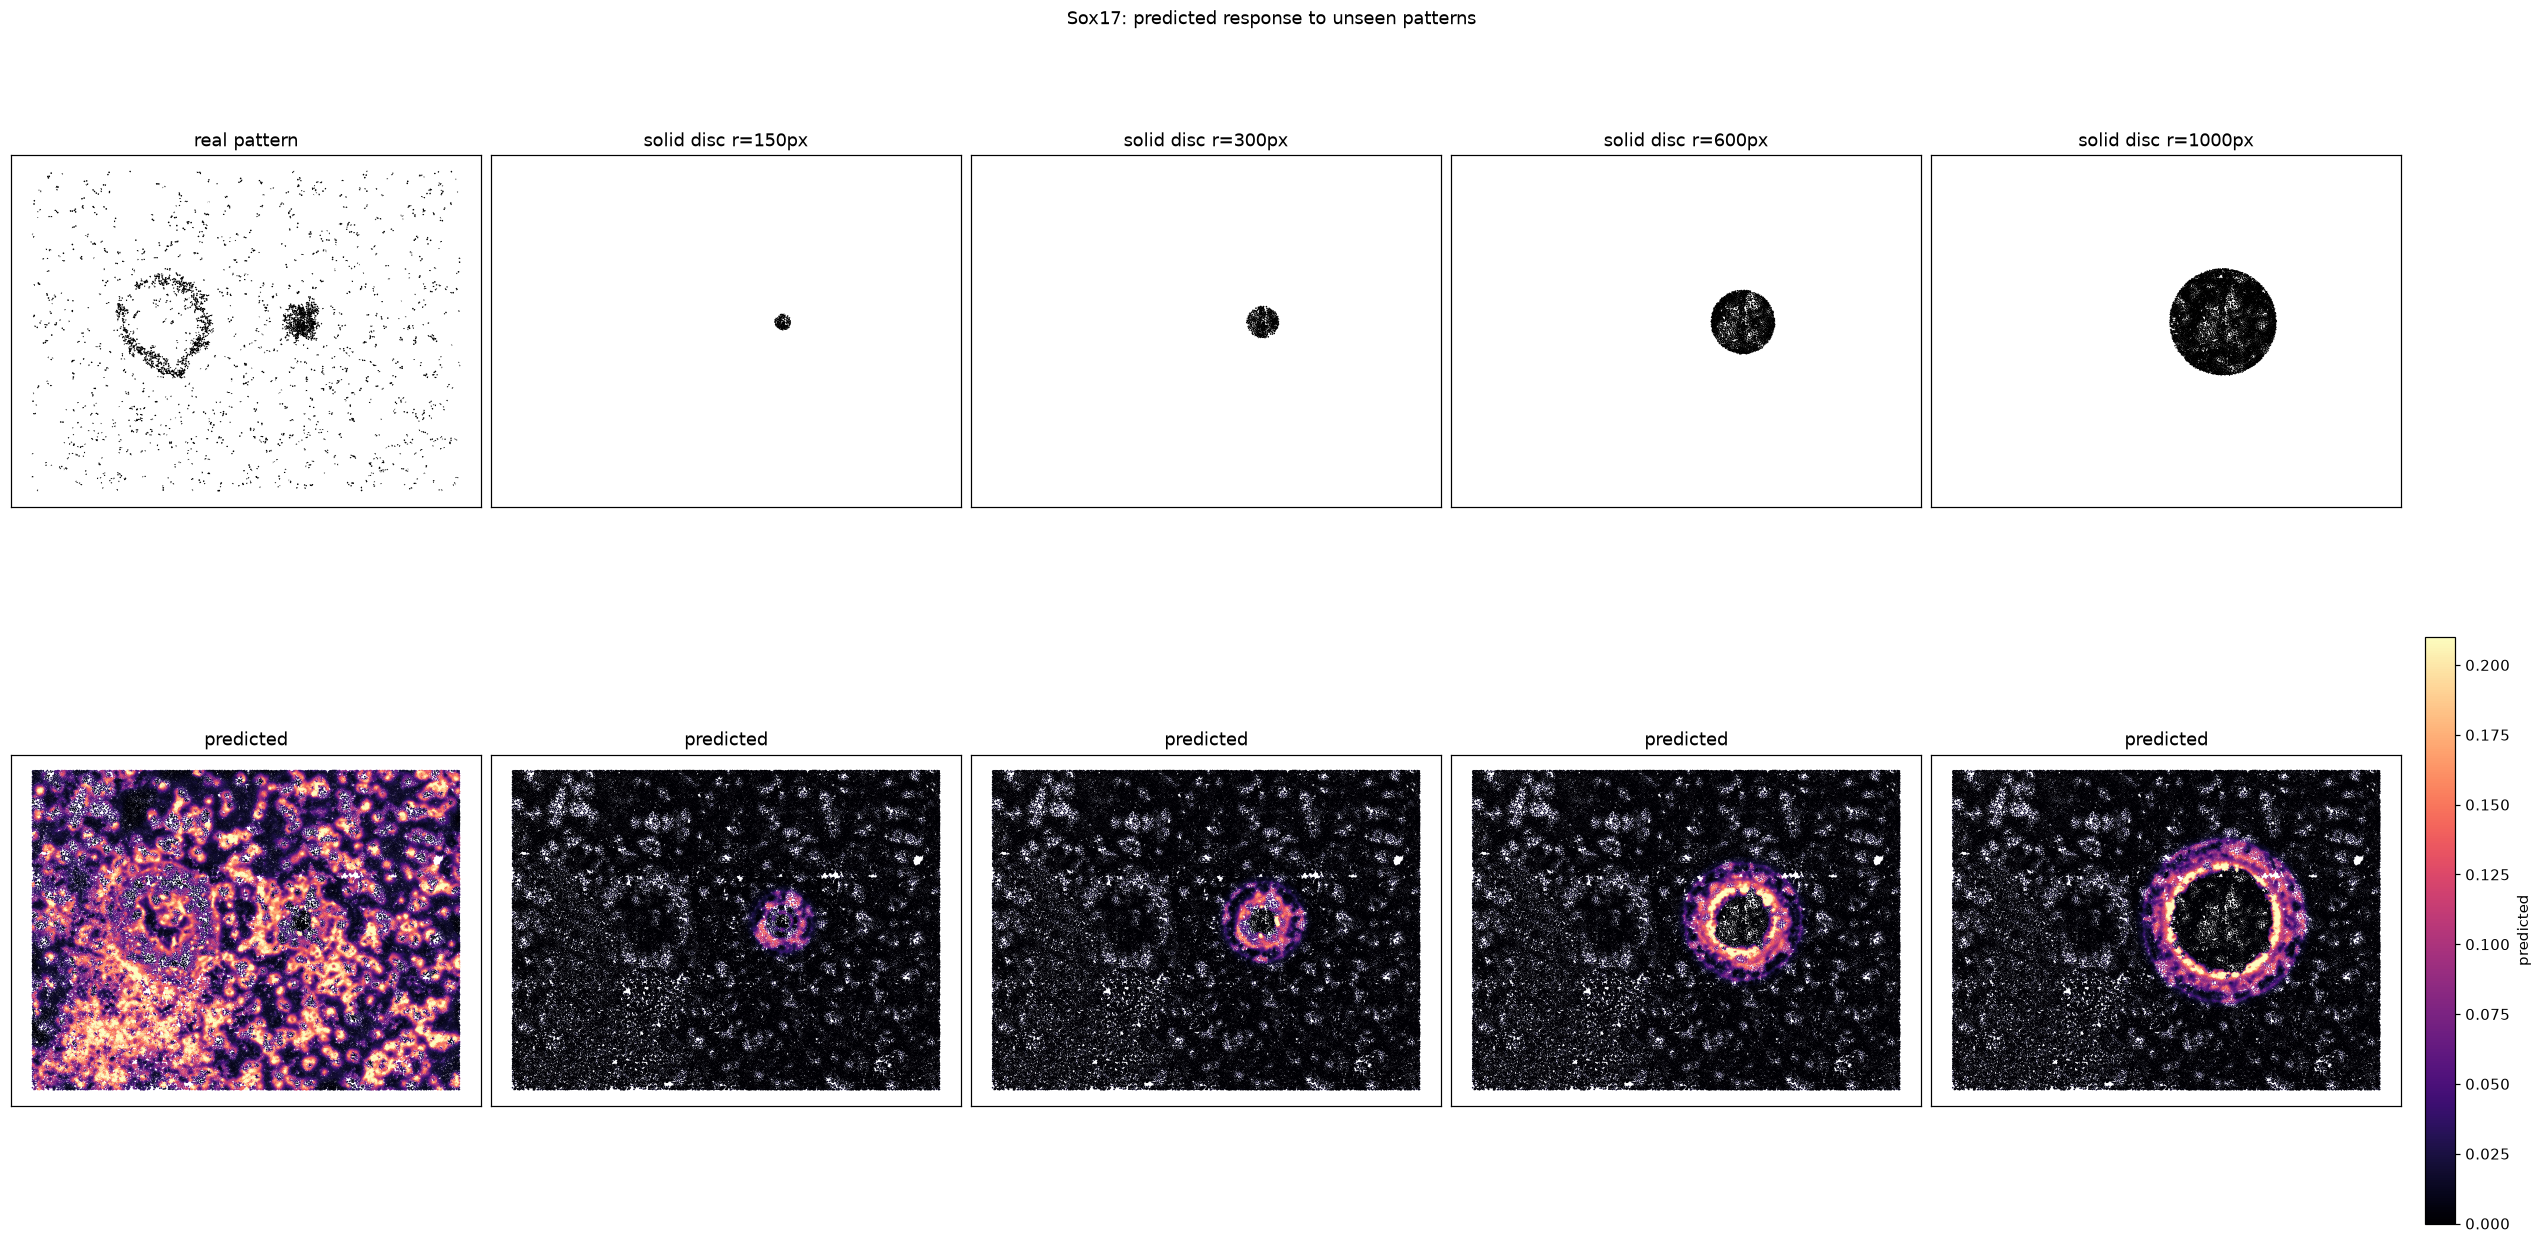

In [13]:
key = ('Sox17', 'BMP4_mask')
model, data, log_w = M[key]['model'], M[key]['data'], M[key]['log_w']
mask_fn = lambda d: recipe.mask_features(d, 'BMP4_bin', max_sigma=recipe.MAX_SIGMA, geometry=True)

centre = pl.estimate_pattern_centre(df, 'BMP4_bin')
RADII = [150, 300, 600, 1000]
dfc = df.copy()

def counterfactual(mask):
    dfc['BMP4_bin'] = mask
    return ip.counterfactual_prediction(dfc, model, data, log_w, mask_fn, device=DEVICE)

panels = [('real pattern', df['BMP4_bin'].to_numpy(), ip.predict(model, data, log_w, device=DEVICE))]
for r in RADII:
    mask = ip.disc_mask(centroids, centre, float(r))
    panels.append((f'solid disc r={r}px', mask, counterfactual(mask)))

fig = pl.plot_counterfactual_panel(df, panels, suptitle=f'{key[0]}: predicted response to unseen patterns')
fig.savefig(f'{FIG_DIR}/counterfactual_patterns.png', dpi=120)

,pattern,radius,peak,peak_at_px,peak_minus_edge,half_max_px_past_peak,interior,rim,just_outside,far
0,solid disc r=150px,150,0.0838,376.0524,226.0524,150.039597,0.0002,0.0419,0.0341,0.0030
1,solid disc r=300px,300,0.1135,276.2256,-23.7744,298.865814,0.0001,0.1032,0.0983,0.0025
2,solid disc r=600px,600,0.2189,625.0724,25.0724,150.577194,0.0002,0.1930,0.1055,0.0024
3,solid disc r=1000px,1000,0.2351,1025.7841,25.7841,100.001801,0.0000,0.1555,0.0653,0.0026


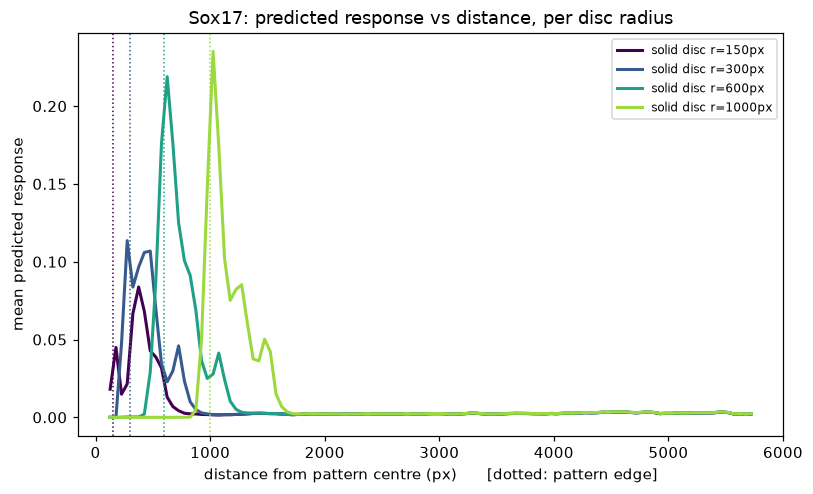

In [14]:
def radial_profile(values, centre, step=50.0, min_cells=50):
    rad = np.hypot(centroids[:,0] - centre[0], centroids[:,1] - centre[1])
    which = np.digitize(rad, np.arange(0, rad.max(), step))
    xs, ys = [], []
    for k in np.unique(which):
        sel = which == k
        if sel.sum() < min_cells:
            continue
        xs.append(rad[sel].mean()); ys.append(np.asarray(values).ravel()[sel].mean())
    return np.array(xs), np.array(ys)

def region_means(pred, radius):
    """Interior / rim / just-outside / far, as means -- the picture above as numbers."""
    r = np.hypot(centroids[:,0] - centre[0], centroids[:,1] - centre[1])
    pred = np.asarray(pred).ravel()
    band = lambda lo, hi: float(pred[(r >= lo * radius) & (r < hi * radius)].mean())
    return dict(interior=band(0, 0.6), rim=band(0.9, 1.1), just_outside=band(1.1, 1.5),
                far=float(pred[r > 2.5 * radius].mean()))

profiles = {label: radial_profile(pred, centre) for label, _, pred in panels[1:]}
ax = pl.plot_response_range(profiles, radii=RADII,
                            title=f'{key[0]}: predicted response vs distance, per disc radius')
ax.figure.savefig(f'{FIG_DIR}/response_range.png', dpi=130)

rows = []
for (label, _, pred), r in zip(panels[1:], RADII):
    d, v = profiles[label]
    peak_at = float(d[np.argmax(v)])
    decayed = d[(d > peak_at) & (v < 0.5 * v.max())]
    rows.append(dict(pattern=label, radius=r, peak=v.max(), peak_at_px=peak_at,
                     peak_minus_edge=peak_at - r,
                     half_max_px_past_peak=(decayed.min() - peak_at) if len(decayed) else np.nan,
                     **region_means(pred, r)))
pd.DataFrame(rows).round(4)

### 6b. Is the ring real, or is a solid disc just out of distribution?

The panels above are solid discs -- every cell inside illuminated. No real `BMP4_bin` looks
like that: it is a per-cell threshold call, so even the brightest region of the real pattern
is a *scattering* of positive cells at some local rate. A solid disc is therefore a mask the
model has never seen, and a sharp structure it predicts there could be extrapolation rather
than a learned rule.

So: hold the radius at 600px and sweep the **fill fraction** instead, from the rate actually
observed inside the real pattern up to solid. If the edge-localised response survives at the
observed fill, it is a property of the learned rule; if it only appears as fill -> 1, it is
an artefact of asking the model an out-of-distribution question.

observed local positive rate inside the real pattern: 0.32


,pattern,fill,interior,rim,just_outside,far
0,"r=600px, fill=0.25",0.25,0.0945,0.1216,0.0496,0.0024
1,"r=600px, fill=0.32",0.32,0.1024,0.1216,0.0583,0.0024
2,"r=600px, fill=0.50",0.50,0.0937,0.1520,0.0904,0.0024
3,"r=600px, fill=1.00",1.00,0.0002,0.1930,0.1055,0.0024


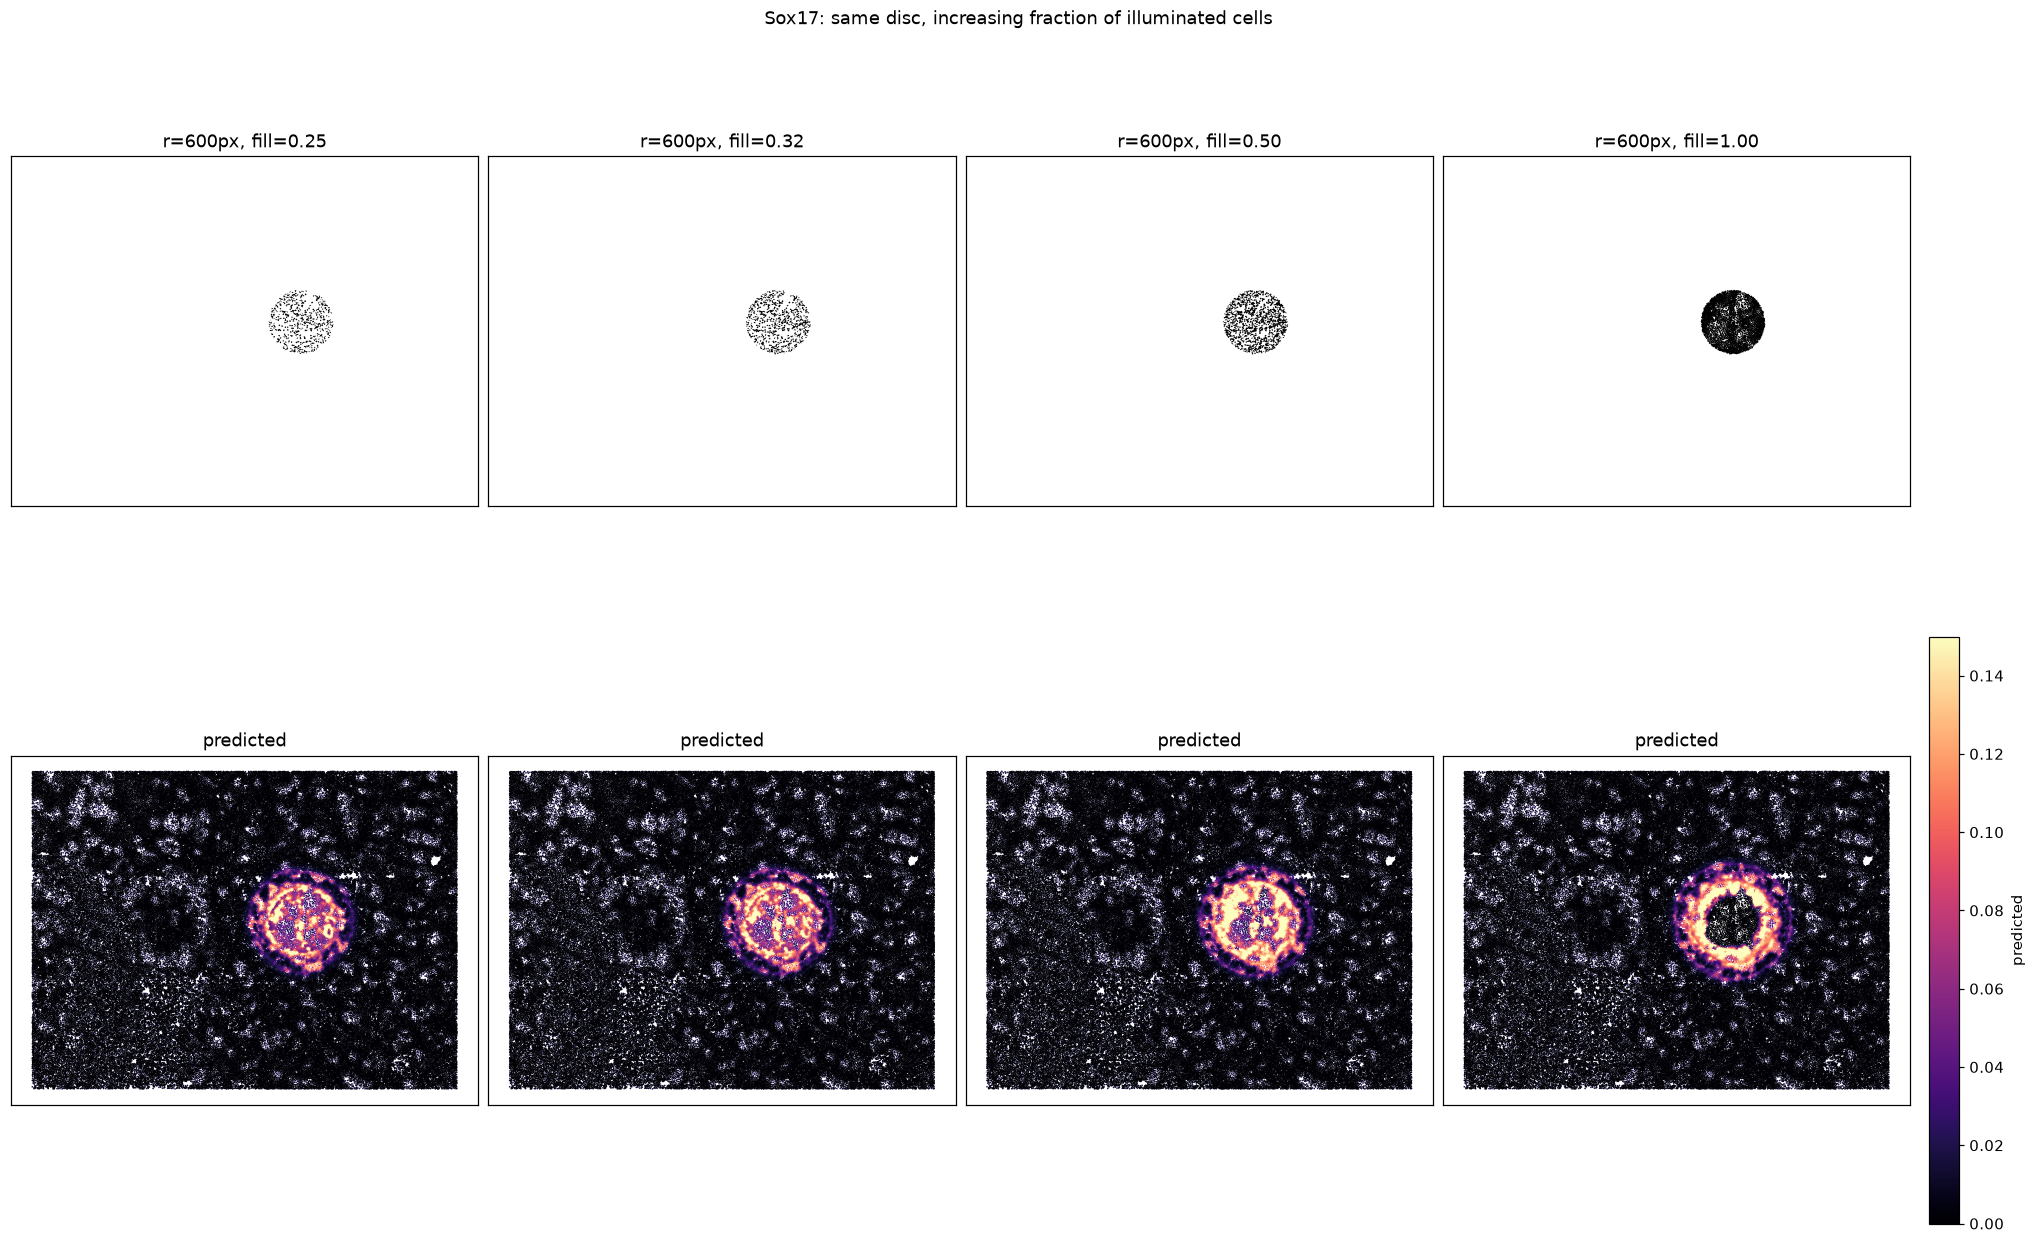

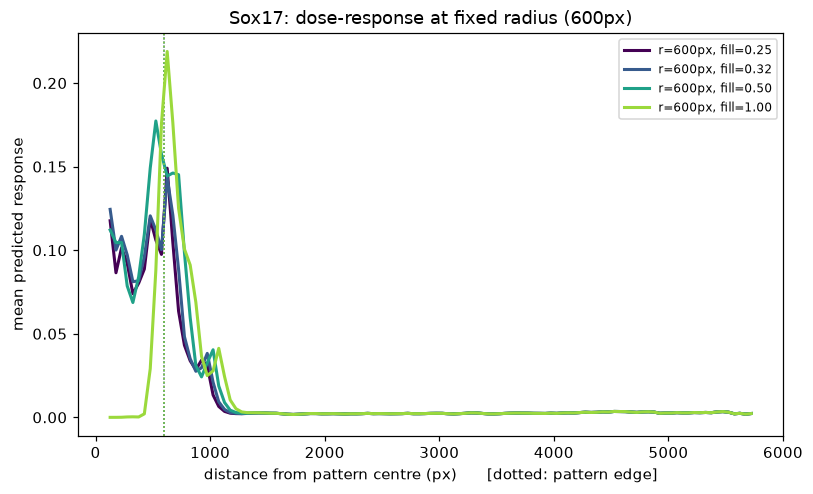

In [15]:
FILL_OBS = float(df['BMP4_bin_gauss_120'].quantile(0.99))   # local positive rate in the real pattern
FILLS = sorted({round(FILL_OBS, 2), 0.25, 0.5, 1.0})
print(f'observed local positive rate inside the real pattern: {FILL_OBS:.2f}')

fill_panels = []
for f in FILLS:
    mask = ip.disc_mask(centroids, centre, 600.0, fill=f, seed=0)
    fill_panels.append((f'r=600px, fill={f:.2f}', mask, counterfactual(mask)))

fig = pl.plot_counterfactual_panel(df, fill_panels,
                                   suptitle=f'{key[0]}: same disc, increasing fraction of illuminated cells')
fig.savefig(f'{FIG_DIR}/counterfactual_fill.png', dpi=120)

fill_profiles = {label: radial_profile(pred, centre) for label, _, pred in fill_panels}
ax = pl.plot_response_range(fill_profiles, radii=[600] * len(FILLS),
                            title=f'{key[0]}: dose-response at fixed radius (600px)')
ax.figure.savefig(f'{FIG_DIR}/response_fill.png', dpi=130)

pd.DataFrame([dict(pattern=label, fill=f, **region_means(pred, 600.0))
              for (label, _, pred), f in zip(fill_panels, FILLS)]).round(4)

## What this says

Numbers below are from the run stored in this notebook: well `W9_pattern1`, the blocked-split
checkpoints, one seed. Re-run and re-read if the models are retrained.

**1. The cell's own illumination status is irrelevant to the prediction.** `BMP4_bin` --
"is *this* cell BMP4+" -- takes 1% of the attribution and costs nothing at all when
destroyed (Sox17 R2 drop -0.0003, AUROC drop 0.002). Everything the model uses is
neighbourhood composition. That is the expected signature of a diffusible signal rather
than a cell-autonomous response, and it is worth knowing that the model found it without
being told.

**2. The prediction is built from a DIFFERENCE between spatial scales, not from a dose.**
For Sox17 the three largest attributions are `gauss_120` at 32% with a *negative* mean
(-0.078), against `gauss_240` at 22% (+0.061) and `gauss_60` at 16% (+0.041). Opposite signs
at neighbouring scales is a difference-of-Gaussians -- a local-contrast operator. The
partial-dependence curves agree: raising `gauss_120` alone *lowers* the predicted response.
So the learned rule is closer to "how much more BMP4 is there here than in the surround"
than to "how much BMP4 is there here".

**3. Which scale carries it is not identifiable -- but which feature decides *who responds*
is.** IG puts 32% on `gauss_120`, yet shuffling it costs only 0.046 R2 while shuffling
`gauss_240` (22% share) costs 0.162: the scales are near-interchangeable, exactly as their
correlation predicts, so no single scale's share should be quoted as a length scale of the
biology. One feature is genuinely irreplaceable: `BMP4_bin_log_dist_pos` -- distance to the
nearest illuminated cell -- costs 0.203 AUROC when shuffled, 5x any other feature. Ranking
(who responds) comes from distance-to-pattern; magnitude comes from the scale pyramid.

**4. Presence and level are learned from different features.** Sox17's classifier branch is
dominated by `gauss_120` (31%) and `gauss_240` (20%) -- 120-240px context decides *whether* a
cell responds -- while the magnitude branch is dominated by `gauss_60` (41%), a much more
local scale, deciding *how strongly*. A 'combined' attribution averages these two into
something neither branch actually does.

**5. The graph does real work, but only locally.** Every layer of every model draws ~24-28%
of its message mass from the cell's own self-loop and the rest from neighbours, with the
per-edge contribution falling to zero at the 30px graph radius by construction. Long-range
context enters as node features (the pyramid), short-range structure through message
passing -- the division of labour the architecture was designed for, confirmed rather than
assumed.

**6. It learned a spatial rule, not this well's map.** On synthetic discs it never saw, the
predicted response tracks the disc: peak 0.084 -> 0.114 -> 0.219 -> 0.235 for radii
150 -> 300 -> 600 -> 1000px, saturating around 600px (consistent with a 240px top pyramid
level plus ~90px of graph reach), and falling to a flat 0.002-0.003 far field regardless of
radius. Beyond the pattern edge the response decays to half within ~100-150px for the larger
discs. That is a dose-response with a length scale, and it is the strongest evidence here
that the model generalises rather than memorises.

**7. The dramatic hollow ring in section 6a is an artefact -- and 6b is why the control
matters.** A *solid* disc is a mask no thresholded channel can produce; at fill = 1.0 the
predicted interior collapses to 0.0002 against a rim of 0.193. At the fill actually observed
inside the real pattern (0.32) the interior fills in (0.102) and sits just below the rim
(0.122). So: modest edge enhancement, not a ring. Had section 6b been skipped, the honest-
looking conclusion from 6a would have been wrong.

**8. Sox17 and T are not the same problem.** Relative to an unstimulated cell, illumination
explains 56% of the predicted Sox17 signal but only 25% of predicted T (11% for the
intensity model) -- T has a large illumination-independent baseline (base rate 0.33 vs 0.16),
so more of its R2 rests on a constant. And T's mask model is fragile in a way Sox17's isn't:
shuffling `gauss_15` costs 0.688 R2 while costing only 0.051 AUROC -- destroying that feature
does not damage the ranking, it destroys the *calibration*, which is the same R2/AUROC
disagreement pattern `calibrated_predict` exists to handle.

### Limits on all of the above

* **The models explain presence, not level.** `r2_positives` is -3.6 (Sox17) and -6.6 (T):
  within the positive population these models explain nothing. Every R2 here comes from
  separating positive cells from negative ones, so read the magnitude-branch results
  (point 4) as "what the branch keys on", not as a validated model of expression level.
* **One well, one split, one seed.** These are the blocked-split checkpoints from
  `train_IF.ipynb` on `W9_pattern1`. Nothing here has been repeated across wells or seeds;
  the cross-well section of `train_IF.ipynb` is the relevant reality check, and its scores
  are substantially worse.
* **Correlated inputs.** Every per-feature number for the pyramid scales is a *split of
  credit between correlated columns*, not a measurement of where the information lives.
  The sign structure across scales (point 2) is far more robust than any single share.
* **Counterfactuals are extrapolation.** Shapes and length scales, yes; absolute predicted
  levels for unseen patterns, no.
